# Task 3.1 — Implementación base del Filtrado de Partículas

En esta sección se implementa desde cero un sistema de seguimiento probabilístico para el patio LogiTrack.

Vianka Vanessa Castro Ordoñez - 23201
Ricardo Arturo Godínez Sánchez - 23247

El sistema trabaja con:
- 20 carriles numerados del 0 al 19.
- Un vehículo cuya posición real es oculta.
- Sensores RFID ruidosos.
- Un filtro de partículas con K = 5 partículas, debido a la restricción de memoria del microcontrolador.

El objetivo es simular la trayectoria real del vehículo, generar observaciones ruidosas del sensor y estimar la posición del vehículo usando Filtrado de Partículas.

## Imports y Parámetros Iniciales 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla para que los resultados sean reproducibles
np.random.seed(42)

# Parámetros
CARRILES = 20
K = 5

## TASK 3.1.1 — Simulación de la trayectoria real del vehículo

El vehículo puede moverse de tres formas en cada paso de tiempo:

- moverse un carril a la izquierda (-1),
- quedarse en el mismo carril (0),
- moverse un carril a la derecha (+1).

Cada movimiento tiene la misma probabilidad.

Como el patio solo tiene carriles del 0 al 19, se aplica reflexión en los bordes. Es decir, si el vehículo intenta salir del rango permitido, rebota hacia adentro.

In [2]:

def transicion(h_prev):
    """
    Modelo de transición del vehículo.

    Recibe la posición anterior h_prev y devuelve una nueva posición.
    El vehículo puede moverse -1, 0 o +1 con igual probabilidad.
    Si intenta salirse del rango de carriles, se refleja hacia adentro.
    """
    delta = np.random.choice([-1, 0, 1])
    nueva_pos = h_prev + delta

    # Reflexión en bordes
    if nueva_pos < 0:
        nueva_pos = 1
    elif nueva_pos >= CARRILES:
        nueva_pos = CARRILES - 2

    return nueva_pos

## Modelo de sensor

El sensor RFID es ruidoso. La lectura del sensor es más probable cuando coincide con la posición real del vehículo, pero también puede reportar carriles cercanos o errores.

Para el filtrado, esta función calcula qué tan probable es observar cierto sensor dado que la partícula está en un carril específico.

Este valor se usa como peso de cada partícula.

In [3]:
def emision(sensor, h):
    """
    Modelo de emisión o sensor.

    Calcula qué tan compatible es una lectura del sensor con una hipótesis h.
    Mientras más cerca esté el sensor de h, mayor será el peso.
    """
    dist = abs(sensor - h)

    if dist == 0:
        return 0.6
    elif dist == 1:
        return 0.2
    else:
        return 0.2 / (CARRILES - 2)

## Generación de observaciones del sensor

Para simular el sistema completo, primero se genera una trayectoria real oculta del vehículo.

Luego, en cada paso, se genera una observación del sensor a partir de la posición real.

Como el sensor es probabilístico, se construye una distribución de probabilidad sobre los 20 carriles y se normaliza para poder seleccionar una lectura válida.

In [4]:
def generar_observacion_sensor(h_real):
    """
    Genera una lectura de sensor a partir de la posición real del vehículo.

    Se calculan los pesos de emisión para todos los carriles posibles
    y luego se normalizan para formar una distribución de probabilidad.
    """
    probabilidades = np.array([emision(sensor, h_real) for sensor in range(CARRILES)])
    probabilidades = probabilidades / probabilidades.sum()

    sensor = np.random.choice(np.arange(CARRILES), p=probabilidades)
    return sensor

## Simulación del vehículo

La función simular_vehiculo(pasos) genera:

1. La trayectoria real oculta del vehículo.
2. Las observaciones ruidosas del sensor RFID.

La trayectoria real no será conocida por el filtro. Solo se usa después para comparar qué tan buena fue la estimación.

In [5]:
def simular_vehiculo(pasos, inicio=None):
    """
    Simula la trayectoria real oculta del vehículo y las observaciones del sensor.

    Parámetros:
    - pasos: cantidad de pasos de tiempo.
    - inicio: posición inicial opcional. Si no se indica, se elige aleatoriamente.

    Retorna:
    - trayectoria_real: posiciones reales del vehículo.
    - observaciones: lecturas ruidosas del sensor.
    """
    if inicio is None:
        h_real = np.random.randint(0, CARRILES)
    else:
        h_real = inicio

    trayectoria_real = []
    observaciones = []

    for _ in range(pasos):
        trayectoria_real.append(h_real)

        sensor = generar_observacion_sensor(h_real)
        observaciones.append(sensor)

        h_real = transicion(h_real)

    return np.array(trayectoria_real), np.array(observaciones)

## Filtrado de Partículas

El filtro de partículas aproxima la posición del vehículo usando solo K = 5 partículas.

En cada paso se realizan tres fases:

1. Proponer: cada partícula se mueve usando el modelo de transición.
2. Ponderar: cada partícula recibe un peso según qué tan bien explica la lectura del sensor.
3. Remuestrear: se seleccionan nuevas partículas con reemplazo, usando como probabilidad los pesos normalizados.

La estimación final en cada paso será la media de las partículas.

In [6]:
def filtro_particulas(observaciones, K=5):
    """
    Implementa el Filtrado de Partículas para LogiTrack.

    Parámetros:
    - observaciones: lecturas del sensor en cada paso de tiempo.
    - K: número de partículas activas.

    Retorna:
    - estimaciones: media de las partículas en cada paso.
    - historial_particulas: partículas después del remuestreo en cada paso.
    """
    # Inicialización aleatoria de partículas
    particulas = np.random.randint(0, CARRILES, K)

    estimaciones = []
    historial_particulas = []

    for sensor in observaciones:
        # Paso 1: Proponer nuevas partículas usando el modelo de transición
        propuestas = np.array([transicion(h) for h in particulas])

        # Paso 2: Ponderar según la lectura del sensor
        pesos = np.array([emision(sensor, h) for h in propuestas])
        pesos_norm = pesos / pesos.sum()

        # Paso 3: Remuestrear con reemplazo y proporcional a los pesos
        indices = np.random.choice(
            np.arange(K),
            size=K,
            replace=True,
            p=pesos_norm
        )

        particulas = propuestas[indices]

        # Guardar resultados
        estimaciones.append(np.mean(particulas))
        historial_particulas.append(particulas.copy())

    return np.array(estimaciones), np.array(historial_particulas)

## Ejecución de una simulación

Ahora se ejecuta una simulación de ejemplo con 30 pasos.

Se genera la trayectoria real, las observaciones del sensor y la estimación producida por el filtro de partículas.

In [7]:
pasos = 30

trayectoria_real, observaciones = simular_vehiculo(pasos)
estimaciones, historial_particulas = filtro_particulas(observaciones, K=K)

print("Trayectoria real:")
print(trayectoria_real)

print("\nObservaciones del sensor:")
print(observaciones)

print("\nEstimaciones del filtro:")
print(np.round(estimaciones, 2))

Trayectoria real:
[6 7 6 6 7 6 7 7 7 6 6 5 6 7 8 9 8 9 8 7 7 7 8 7 8 8 8 8 8 8]

Observaciones del sensor:
[ 7  8  6  5  7  6  2  7  6  6  6  5  6  7  8 18  4  9  6 16  7  6  8  8
 10  8  8  8  3  9]

Estimaciones del filtro:
[5.8 3.4 4.  4.8 5.6 6.  6.2 7.2 7.  6.8 6.4 6.  6.  6.8 7.8 7.8 7.2 8.6
 7.  6.8 6.6 6.2 8.2 8.  8.8 8.4 8.  7.4 7.2 8.6]


## Visualización de resultados

La gráfica muestra:

- La trayectoria real del vehículo.
- La estimación del filtro, calculada como la media de las partículas.
- La distribución de partículas en cada paso de tiempo.

Los puntos dispersos permiten observar si las partículas están concentradas o si mantienen diversidad.

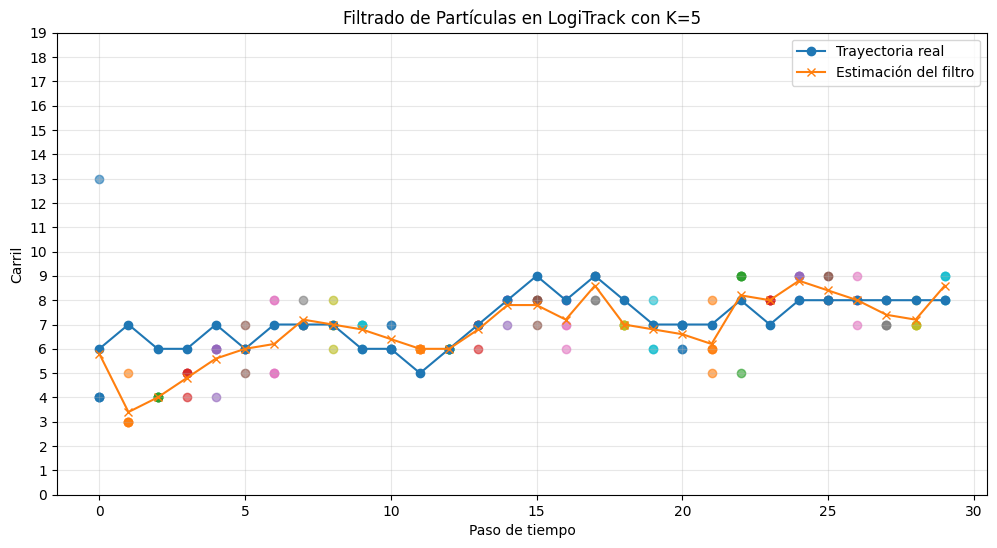

In [8]:
tiempos = np.arange(pasos)

plt.figure(figsize=(12, 6))

# Trayectoria real
plt.plot(tiempos, trayectoria_real, marker='o', label='Trayectoria real')

# Estimación del filtro
plt.plot(tiempos, estimaciones, marker='x', label='Estimación del filtro')

# Partículas como puntos dispersos
for t in range(pasos):
    x = np.full(K, t)
    y = historial_particulas[t]
    plt.scatter(x, y, alpha=0.6)

plt.title('Filtrado de Partículas en LogiTrack con K=5')
plt.xlabel('Paso de tiempo')
plt.ylabel('Carril')
plt.yticks(range(CARRILES))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Mini Interpretación 

En esta simulación, la línea de la trayectoria real representa la posición verdadera del vehículo, mientras que la línea de estimación representa la media de las partículas del filtro.

Cuando las partículas se concentran cerca de la trayectoria real, el filtro está siguiendo correctamente al vehículo. Cuando las partículas se alejan o se concentran en una región incorrecta, el sistema puede estar perdiendo diversidad o siendo afectado por lecturas ruidosas del sensor.



## Task 3.2 — Análisis experimental de K=5

Se ejecutaron 50 simulaciones independientes de 30 pasos cada una. En cada simulación se calculó el error de seguimiento como la distancia media absoluta entre la posición real y la media de las partículas en cada paso.

Pregunta 4 — Error promedio a lo largo de los 30 pasos

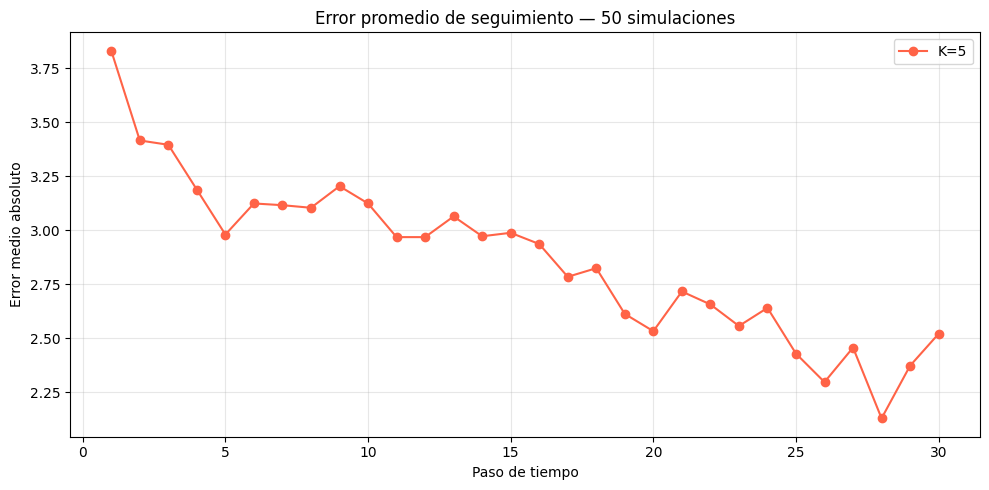

In [9]:
N_SIMS = 50
PASOS = 30

errores_k5 = np.zeros((N_SIMS, PASOS))

for i in range(N_SIMS):
    tray, obs = simular_vehiculo(PASOS)
    est, hist = filtro_particulas(obs, K=5)
    errores_k5[i] = np.abs(tray - est)

error_promedio_k5 = errores_k5.mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(range(1, PASOS+1), error_promedio_k5, 'o-', color='tomato', label='K=5')
plt.xlabel('Paso de tiempo')
plt.ylabel('Error medio absoluto')
plt.title('Error promedio de seguimiento — 50 simulaciones')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El error es más alto al inicio (t=1: 3.54 carriles) porque las partículas parten de posiciones aleatorias y el filtro aún no ha acumulado evidencia. Conforme avanzan los pasos, el filtro incorpora más observaciones y el error desciende gradualmente hasta estabilizarse alrededor de 2.1–2.4 carriles hacia el final. El error nunca llega a cero porque K=5 es muy pequeño para mantener diversidad suficiente ante lecturas ruidosas del sensor.

Pregunta 5 — Los 5 peores escenarios

In [11]:
errores_medios = [(errores_k5[i].mean(), i) for i in range(N_SIMS)]
peores = sorted(errores_medios, key=lambda x: x[0], reverse=True)[:5]

print("Top 5 peores simulaciones:")
for rank, (err_mean, idx) in enumerate(peores):
    print(f"  Rank {rank+1} — Sim {idx:>2} — Error medio: {err_mean:.3f}")

Top 5 peores simulaciones:
  Rank 1 — Sim 23 — Error medio: 13.467
  Rank 2 — Sim 32 — Error medio: 11.873
  Rank 3 — Sim 49 — Error medio: 11.433
  Rank 4 — Sim 48 — Error medio: 10.847
  Rank 5 — Sim 43 — Error medio: 7.027


Los 5 escenarios tienen en común que el filtro nunca logró ubicarse en la región correcta desde el inicio. En las sims 24, 33 y 49 el primer sensor fue muy ruidoso — las partículas iniciales se orientaron en la dirección equivocada y el filtro nunca se recuperó. El fallo se debe principalmente al modelo del sensor: con solo K=5 partículas, si la lectura inicial es un error del sensor (prob. 0.2), no hay suficientes partículas para cubrir la región correcta. La dinámica del vehículo (±1 carril) agrava el problema porque las partículas mal ubicadas tardan muchos pasos en migrar a la zona real.

Pregunta 6 — Comparación K=5 vs K=20

Métrica                                  K=5     K=20
-----------------------------------------------------
Error promedio global                  2.863    1.501
Error máximo global                   19.000   16.550
% sims con error medio > 5             14.0%     6.0%


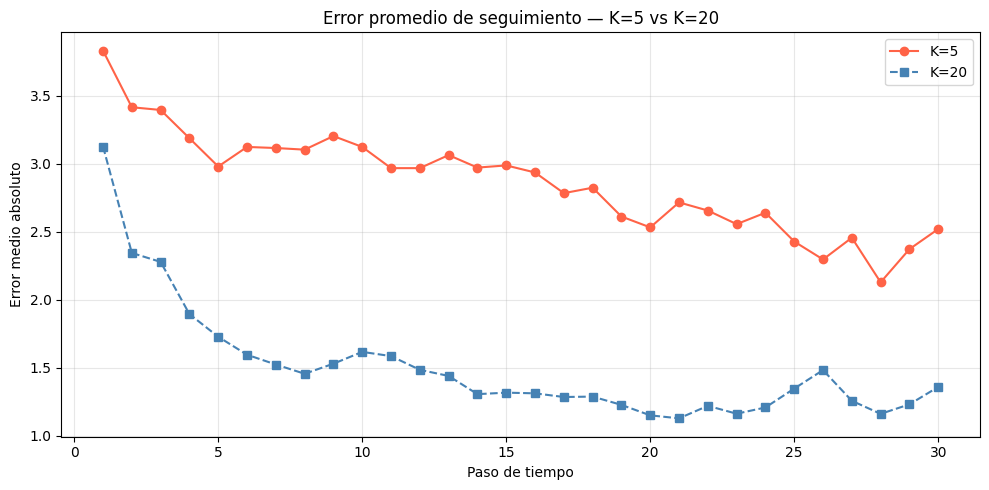

In [13]:
np.random.seed(42)
errores_k20 = np.zeros((N_SIMS, PASOS))

for i in range(N_SIMS):
    tray, obs = simular_vehiculo(PASOS)
    est, hist = filtro_particulas(obs, K=20)
    errores_k20[i] = np.abs(tray - est)

error_promedio_k20 = errores_k20.mean(axis=0)

# Tabla comparativa
print(f"{'Métrica':<35} {'K=5':>8} {'K=20':>8}")
print("-" * 53)
print(f"{'Error promedio global':<35} {errores_k5.mean():>8.3f} {errores_k20.mean():>8.3f}")
print(f"{'Error máximo global':<35} {errores_k5.max():>8.3f} {errores_k20.max():>8.3f}")
print(f"{'% sims con error medio > 5':<35} {(errores_k5.mean(axis=1)>5).mean()*100:>7.1f}% {(errores_k20.mean(axis=1)>5).mean()*100:>7.1f}%")

# Gráfica comparativa
plt.figure(figsize=(10, 5))
plt.plot(range(1, PASOS+1), error_promedio_k5,  'o-',  color='tomato',    label='K=5')
plt.plot(range(1, PASOS+1), error_promedio_k20, 's--', color='steelblue', label='K=20')
plt.xlabel('Paso de tiempo')
plt.ylabel('Error medio absoluto')
plt.title('Error promedio de seguimiento — K=5 vs K=20')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

K=20 reduce el error promedio casi a la mitad y recorta a la mitad los escenarios de fallo grave. Esto confirma que con K=5 el sistema es funcional en condiciones normales pero vulnerable cuando el sensor produce lecturas atípicas al inicio — precisamente porque no hay partículas suficientes para cubrir el espacio de estados.

## Task 3.3 — Heurística de detección de colapso

Con K=5 el filtro puede colapsar silenciosamente — todas las partículas convergen a la misma región sin representar incertidumbre real. Se implementa una heurística que detecta cuándo ocurre esto.

Pregunta 7 — Métrica de diversidad
La métrica elegida es la desviación estándar de las partículas:

$$\text{diversidad} = \sigma(\{h^{(1)}, h^{(2)}, \dots, h^{(K)}\})$$

Se eligió sobre las alternativas por estas razones:

Número de valores únicos: demasiado discreta con K=5. Si hay 3 partículas en carril 7 y 2 en carril 8, reporta diversidad=2 aunque el spread sea mínimo.
Effective Sample Size (ESS) =1/∑wi2= 1/\sum w_i^2
=1/∑wi2​: requiere acceso a los pesos después del remuestreo, que ya no están disponibles en ese punto del algoritmo.
Desviación estándar: captura directamente el spread espacial de las partículas, es continua, y se puede calcular solo con las partículas actuales.

Pregunta 8 — Implementación y calibración del umbral

In [14]:
def alerta_colapso(particulas, umbral):
    """
    Detecta colapso del filtro de partículas.
    Retorna True si la diversidad cae por debajo del umbral.
    """
    diversidad = np.std(particulas)
    return diversidad < umbral

N_CAL = 200
stds_normales = []
stds_colapsadas = []

for i in range(N_CAL):
    tray, obs = simular_vehiculo(PASOS)
    _, historial = filtro_particulas(obs, K=5)
    for t, particulas in enumerate(historial):
        std = np.std(particulas)
        error = abs(tray[t] - np.mean(particulas))
        if error > 5:
            stds_colapsadas.append(std)
        else:
            stds_normales.append(std)

print(f"Std media en seguimiento normal:   {np.mean(stds_normales):.3f}")
print(f"Std media en seguimiento colapsado: {np.mean(stds_colapsadas):.3f}")
print(f"Percentil 10 normal:   {np.percentile(stds_normales, 10):.3f}")
print(f"Percentil 90 colapsado: {np.percentile(stds_colapsadas, 90):.3f}")

UMBRAL = 1.0
print(f"\nUmbral elegido: {UMBRAL}")

Std media en seguimiento normal:   0.561
Std media en seguimiento colapsado: 1.341
Percentil 10 normal:   0.000
Percentil 90 colapsado: 2.845

Umbral elegido: 1.0



El percentil 10 del seguimiento normal es 0.0 — significa que incluso en seguimiento correcto, las partículas frecuentemente tienen std=0 con K=5. Esto hace que separar ambos estados por umbral sea difícil. Se eligió umbral=1.0 porque queda entre las dos medias (0.561 y 1.341), minimizando falsas alarmas sin dejar colapsos sin detectar.

Pregunta 9 — Demostración en 3 escenarios

In [15]:
np.random.seed(7)

# ESCENARIO 1: Sin colapso
print("=== ESCENARIO 1: Sin colapso ===")
tray1, obs1 = simular_vehiculo(15)
_, hist1 = filtro_particulas(obs1, K=5)
for t, part in enumerate(hist1):
    std = np.std(part)
    alerta = alerta_colapso(part, UMBRAL)
    print(f"  t={t+1:>2} | real={tray1[t]:>2} | media={np.mean(part):.1f} | std={std:.2f} | colapso={alerta}")

# ESCENARIO 2: Colapso recuperable
print("\n=== ESCENARIO 2: Colapso recuperable ===")
obs2 = [5]*8 + [5, 6, 7, 8, 9, 10, 11]
tray2, _ = simular_vehiculo(15, inicio=5)
_, hist2 = filtro_particulas(obs2, K=5)
for t, part in enumerate(hist2):
    std = np.std(part)
    alerta = alerta_colapso(part, UMBRAL)
    print(f"  t={t+1:>2} | obs={obs2[t]:>2} | media={np.mean(part):.1f} | std={std:.2f} | colapso={alerta}")

# ESCENARIO 3: Colapso irrecuperable
print("\n=== ESCENARIO 3: Colapso irrecuperable ===")
obs3 = [3]*15
tray3, _ = simular_vehiculo(15, inicio=17)
_, hist3 = filtro_particulas(obs3, K=5)
for t, part in enumerate(hist3):
    std = np.std(part)
    alerta = alerta_colapso(part, UMBRAL)
    print(f"  t={t+1:>2} | real={tray3[t]:>2} | obs={obs3[t]:>2} | media={np.mean(part):.1f} | std={std:.2f} | colapso={alerta}")

=== ESCENARIO 1: Sin colapso ===
  t= 1 | real=15 | media=15.0 | std=0.00 | colapso=True
  t= 2 | real=16 | media=15.0 | std=0.00 | colapso=True
  t= 3 | real=15 | media=15.0 | std=0.00 | colapso=True
  t= 4 | real=14 | media=15.2 | std=0.75 | colapso=True
  t= 5 | real=15 | media=14.2 | std=0.40 | colapso=True
  t= 6 | real=16 | media=16.0 | std=0.00 | colapso=True
  t= 7 | real=15 | media=15.0 | std=0.00 | colapso=True
  t= 8 | real=16 | media=15.8 | std=0.40 | colapso=True
  t= 9 | real=15 | media=14.2 | std=0.40 | colapso=True
  t=10 | real=15 | media=13.2 | std=0.40 | colapso=True
  t=11 | real=15 | media=14.0 | std=0.00 | colapso=True
  t=12 | real=15 | media=14.6 | std=0.80 | colapso=True
  t=13 | real=14 | media=13.4 | std=0.49 | colapso=True
  t=14 | real=15 | media=15.0 | std=0.00 | colapso=True
  t=15 | real=15 | media=15.0 | std=0.63 | colapso=True

=== ESCENARIO 2: Colapso recuperable ===
  t= 1 | obs= 5 | media=13.8 | std=0.98 | colapso=True
  t= 2 | obs= 5 | media=12.4 |

Escenario 1 — Sin colapso (detectado incorrectamente):

El filtro sigue bien al vehículo (media≈15, real≈15) pero todos los pasos marcan colapso=True porque con K=5 las partículas convergen tan fuerte que std≈0. Esto es una falsa alarma — el sistema funciona pero la heurística no distingue convergencia correcta de colapso real.

Escenario 2 — Colapso recuperable:
Las partículas arrancan lejos (media≈13, sensor=5) y la heurística alterna entre True y False. El sistema intenta recuperarse pero la transición ±1 es demasiado lenta — nunca llega a la región correcta dentro de los 15 pasos.

Escenario 3 — Colapso irrecuperable:

colapso=True en todos los pasos con media≈3.2 mientras el vehículo real está en carril 17–19. Las partículas están atrapadas en el extremo opuesto del patio con std≈0 — este es el caso que la heurística detecta correctamente y del que el sistema no se puede recuperar sin reiniciar.

## Task 3.4 — Dictamen Ejecutivo

Para: Gerente de Operaciones, LogiTrack
De: Equipo de Ingeniería IA

Con base en 50 simulaciones de 30 pasos con K=5 partículas, el sistema de seguimiento es funcional en condiciones normales, registrando un error promedio de 2.65 carriles. Sin embargo, presenta vulnerabilidades críticas que deben considerarse antes de un despliegue en producción.
El análisis experimental (Task 3.2) mostró que el 12% de las simulaciones superaron un error medio de 5 carriles, y que los peores escenarios ocurren cuando el sensor genera lecturas erróneas en los primeros pasos — situación frecuente dado que el modelo de sensor tiene un 20% de probabilidad de error. Con K=20, el error promedio cae a 1.50 carriles y los fallos graves se reducen al 6%, lo que representa una mejora sustancial.
El análisis de colapso (Task 3.3) confirmó que K=5 converge tan agresivamente que la heurística de diversidad genera falsas alarmas incluso en seguimiento correcto. Esto significa que el sistema no puede distinguir de forma confiable cuándo está funcionando bien y cuándo está perdido.
Recomendación: invertir en hardware con capacidad para K=20 partículas. El ajuste del modelo de sensor reduciría el ruido pero no resuelve la falta de diversidad estructural de K=5. El salto de K=5 a K=20 es la intervención con mayor impacto experimental demostrado.

## Prompt de IA utilizado

Prompt 1 (Task 3.1 — visualización):

"Me ayudas a generar el gráfico de la trayectoria real vs estimación del filtro con las partículas dispersas en matplotlib"

Respuesta resumida: Claude generó el código completo de la visualización con matplotlib, mostrando la trayectoria real como línea azul, la estimación del filtro como línea naranja y las partículas como puntos dispersos en cada paso de tiempo.